# Task 1: FedSGD vs Centralized SGD
**Goal: Demonstrate theoretical equivalence between FedSGD and centralized training**


## 0. Setup

In [7]:
import sys
sys.path.insert(1, '/kaggle/input/scriptsfl')

In [10]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, ConcatDataset

from data_utils import load_dataset, create_iid_split, get_dataloaders
from models import SimpleCNN, get_model
from federated_utils import get_model_weights, set_model_weights, aggregate_weights, evaluate_model
from results_utils import save_results

torch.manual_seed(42)
np.random.seed(42)

print("="*80)
print("TASK 1: FEDSGD VS CENTRALIZED SGD")
print("="*80)

#%% Configuration
CONFIG = {
    'dataset': 'cifar10',
    'num_clients': 5,
    'num_iterations': 20,  # Number of SGD steps (NOT rounds/epochs)
    'batch_size': 64,
    'lr': 0.01,
    'momentum': 0.9,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

print(f"\nDevice: {CONFIG['device']}")
print(f"Configuration: {CONFIG}\n")

TASK 1: FEDSGD VS CENTRALIZED SGD


In [11]:
#%% Load data
train_dataset, test_dataset = load_dataset(CONFIG['dataset'])
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# Create IID split for clients
client_indices = create_iid_split(train_dataset, CONFIG['num_clients'])
client_loaders = get_dataloaders(train_dataset, client_indices,
                                  batch_size=CONFIG['batch_size'], shuffle=False)
# NOTE: shuffle=False ensures deterministic ordering for comparison
client_ids = sorted(client_loaders.keys())


100%|██████████| 170M/170M [00:05<00:00, 31.6MB/s] 


## PART 1: FedSGD Implementation
FedSGD: Each client does 1 gradient step, then aggregates
This is equivalent to computing gradient on all data and taking 1 step

In [12]:
print("--- Running FedSGD (K=1) ---")

# Initialize model for FedSGD and cache the initial weights for comparison
model_fedsgd = get_model('simplecnn', num_classes=10, dataset=CONFIG['dataset']).to(CONFIG['device'])
initial_global_weights = get_model_weights(model_fedsgd)
set_model_weights(model_fedsgd, initial_global_weights)

criterion = nn.CrossEntropyLoss()

# History tracking
fedsgd_history = {
    'iterations': [],
    'test_accuracy': [],
    'test_loss': [],
    'model_norm': [],
    'train_loss': [],
    'weight_history': []
}

for iteration in range(CONFIG['num_iterations']):
    # Each client starts from the exact same global weights
    global_weights = get_model_weights(model_fedsgd)
    client_weights = []
    client_sizes = []
    client_losses = []

    for client_id in client_ids:
        loader = client_loaders[client_id]
        client_data_size = len(loader.dataset)

        # Build a fresh local model that mirrors the global parameters
        local_model = get_model('simplecnn', num_classes=10, dataset=CONFIG['dataset']).to(CONFIG['device'])
        set_model_weights(local_model, global_weights)
        local_model.train()

        optimizer = optim.SGD(local_model.parameters(), lr=CONFIG['lr'], momentum=CONFIG['momentum'])
        optimizer.zero_grad()
        running_loss = 0.0

        # Compute the gradient over the ENTIRE local dataset before taking a single SGD step
        for data, target in loader:
            data, target = data.to(CONFIG['device']), target.to(CONFIG['device'])
            output = local_model(data)
            loss = criterion(output, target)
            running_loss += loss.item() * data.size(0)

            # Scale each batch loss so that the accumulated gradient equals the full-batch gradient
            scaled_loss = loss * (data.size(0) / client_data_size)
            scaled_loss.backward()

        optimizer.step()

        client_weights.append(get_model_weights(local_model))
        client_sizes.append(client_data_size)
        client_losses.append(running_loss / client_data_size)

    # Aggregate the single-step updates from all clients – FedSGD
    aggregated_weights = aggregate_weights(client_weights, client_sizes)
    set_model_weights(model_fedsgd, aggregated_weights)

    # Evaluate global model after this communication round
    test_acc, test_loss = evaluate_model(model_fedsgd, test_loader, CONFIG['device'])
    model_norm = sum(torch.norm(p).item() for p in model_fedsgd.parameters())
    avg_train_loss = float(np.average(client_losses, weights=client_sizes))

    fedsgd_history['iterations'].append(iteration + 1)
    fedsgd_history['test_accuracy'].append(test_acc)
    fedsgd_history['test_loss'].append(test_loss)
    fedsgd_history['model_norm'].append(model_norm)
    fedsgd_history['train_loss'].append(avg_train_loss)
    fedsgd_history['weight_history'].append([w.clone() for w in aggregated_weights])

    print(f"Iteration {iteration + 1:02d} | Test Acc: {test_acc:.2f}% | Test Loss: {test_loss:.4f} | Train Loss: {avg_train_loss:.4f}")


--- Running FedSGD (K=1) ---
Iteration 01 | Test Acc: 8.55% | Test Loss: 2.3041 | Train Loss: 2.3072
Iteration 02 | Test Acc: 8.47% | Test Loss: 2.3032 | Train Loss: 2.3062
Iteration 03 | Test Acc: 8.61% | Test Loss: 2.3023 | Train Loss: 2.3049
Iteration 04 | Test Acc: 8.72% | Test Loss: 2.3014 | Train Loss: 2.3039
Iteration 05 | Test Acc: 8.83% | Test Loss: 2.3005 | Train Loss: 2.3028
Iteration 06 | Test Acc: 9.04% | Test Loss: 2.2997 | Train Loss: 2.3018
Iteration 07 | Test Acc: 9.23% | Test Loss: 2.2988 | Train Loss: 2.3011
Iteration 08 | Test Acc: 9.51% | Test Loss: 2.2980 | Train Loss: 2.3007
Iteration 09 | Test Acc: 9.63% | Test Loss: 2.2971 | Train Loss: 2.2998
Iteration 10 | Test Acc: 9.92% | Test Loss: 2.2963 | Train Loss: 2.2987
Iteration 11 | Test Acc: 10.12% | Test Loss: 2.2955 | Train Loss: 2.2977
Iteration 12 | Test Acc: 10.47% | Test Loss: 2.2947 | Train Loss: 2.2969
Iteration 13 | Test Acc: 10.67% | Test Loss: 2.2939 | Train Loss: 2.2961
Iteration 14 | Test Acc: 10.92% 

## PART 2: Centralized SGD Implementation
Centralized: Combine all data, compute gradient, take 1 step

In [13]:
print("--- Running Centralized SGD ---")

# Combine all client data into one dataset so that each step sees the entire data distribution
all_data = ConcatDataset([client_loaders[i].dataset for i in client_ids])
centralized_loader = DataLoader(all_data, batch_size=CONFIG['batch_size'], shuffle=False)

torch.manual_seed(42)
model_centralized = get_model('simplecnn', num_classes=10, dataset=CONFIG['dataset']).to(CONFIG['device'])
set_model_weights(model_centralized, initial_global_weights)

centralized_history = {
    'iterations': [],
    'test_accuracy': [],
    'test_loss': [],
    'model_norm': [],
    'train_loss': [],
    'weight_history': []
}

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_centralized.parameters(), lr=CONFIG['lr'], momentum=CONFIG['momentum'])
total_samples = len(centralized_loader.dataset)

for iteration in range(CONFIG['num_iterations']):
    model_centralized.train()
    optimizer.zero_grad()
    running_loss = 0.0

    # Compute the gradient on the ENTIRE dataset before applying a single SGD step
    for data, target in centralized_loader:
        data, target = data.to(CONFIG['device']), target.to(CONFIG['device'])
        output = model_centralized(data)
        loss = criterion(output, target)
        running_loss += loss.item() * data.size(0)

        scaled_loss = loss * (data.size(0) / total_samples)
        scaled_loss.backward()

    optimizer.step()

    test_acc, test_loss = evaluate_model(model_centralized, test_loader, CONFIG['device'])
    model_norm = sum(torch.norm(p).item() for p in model_centralized.parameters())
    train_loss = running_loss / total_samples

    centralized_history['iterations'].append(iteration + 1)
    centralized_history['test_accuracy'].append(test_acc)
    centralized_history['test_loss'].append(test_loss)
    centralized_history['model_norm'].append(model_norm)
    centralized_history['train_loss'].append(train_loss)
    centralized_history['weight_history'].append(get_model_weights(model_centralized))

    print(f"Iteration {iteration + 1:02d} | Test Acc: {test_acc:.2f}% | Test Loss: {test_loss:.4f} | Train Loss: {train_loss:.4f}")


--- Running Centralized SGD ---
Iteration 01 | Test Acc: 8.59% | Test Loss: 2.3041 | Train Loss: 2.3074
Iteration 02 | Test Acc: 8.58% | Test Loss: 2.3023 | Train Loss: 2.3061
Iteration 03 | Test Acc: 9.02% | Test Loss: 2.3000 | Train Loss: 2.3040
Iteration 04 | Test Acc: 9.91% | Test Loss: 2.2972 | Train Loss: 2.3011
Iteration 05 | Test Acc: 11.13% | Test Loss: 2.2940 | Train Loss: 2.2984
Iteration 06 | Test Acc: 12.62% | Test Loss: 2.2905 | Train Loss: 2.2952
Iteration 07 | Test Acc: 13.33% | Test Loss: 2.2868 | Train Loss: 2.2924
Iteration 08 | Test Acc: 14.37% | Test Loss: 2.2828 | Train Loss: 2.2888
Iteration 09 | Test Acc: 15.57% | Test Loss: 2.2785 | Train Loss: 2.2848
Iteration 10 | Test Acc: 16.63% | Test Loss: 2.2739 | Train Loss: 2.2808
Iteration 11 | Test Acc: 17.53% | Test Loss: 2.2689 | Train Loss: 2.2768
Iteration 12 | Test Acc: 18.10% | Test Loss: 2.2637 | Train Loss: 2.2727
Iteration 13 | Test Acc: 18.91% | Test Loss: 2.2581 | Train Loss: 2.2670
Iteration 14 | Test Acc

## PART 3: Comparison and Verification

In [ ]:
print("" + "="*80)
print("COMPARING FEDSGD VS CENTRALIZED")
print("="*80)

# Parameter differences after each synchronized step
weight_diffs = []
for idx in range(CONFIG['num_iterations']):
    fed_weights = fedsgd_history['weight_history'][idx]
    central_weights = centralized_history['weight_history'][idx]
    diff = sum(torch.norm(f - c).item() for f, c in zip(fed_weights, central_weights))
    weight_diffs.append(diff)

param_diff = weight_diffs[-1]
print(f"Max per-iteration parameter difference: {max(weight_diffs):.6f}")
print(f"Final parameter difference: {param_diff:.6f}")
print("(Values near zero confirm the theoretical equivalence.)")

# Accuracy gap per iteration
acc_diff = [abs(a1 - a2) for a1, a2 in zip(fedsgd_history['test_accuracy'], centralized_history['test_accuracy'])]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Test Accuracy
axes[0, 0].plot(fedsgd_history['iterations'], fedsgd_history['test_accuracy'], marker='o', label='FedSGD', linewidth=2)
axes[0, 0].plot(centralized_history['iterations'], centralized_history['test_accuracy'], marker='s', label='Centralized', linewidth=2, linestyle='--')
axes[0, 0].set_xlabel('Iterations')
axes[0, 0].set_ylabel('Test Accuracy (%)')
axes[0, 0].set_title('Test Accuracy Comparison')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Test Loss
axes[0, 1].plot(fedsgd_history['iterations'], fedsgd_history['test_loss'], marker='o', label='FedSGD', linewidth=2)
axes[0, 1].plot(centralized_history['iterations'], centralized_history['test_loss'], marker='s', label='Centralized', linewidth=2, linestyle='--')
axes[0, 1].set_xlabel('Iterations')
axes[0, 1].set_ylabel('Test Loss')
axes[0, 1].set_title('Test Loss Comparison')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Model Norm
axes[1, 0].plot(fedsgd_history['iterations'], fedsgd_history['model_norm'], marker='o', label='FedSGD', linewidth=2)
axes[1, 0].plot(centralized_history['iterations'], centralized_history['model_norm'], marker='s', label='Centralized', linewidth=2, linestyle='--')
axes[1, 0].set_xlabel('Iterations')
axes[1, 0].set_ylabel('Model Norm')
axes[1, 0].set_title('Model Parameter Norm Comparison')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Accuracy & parameter difference
axes[1, 1].plot(fedsgd_history['iterations'], acc_diff, marker='o', linewidth=2, color='tab:red', label='|Accuracy Gap|')
axes[1, 1].set_xlabel('Iterations')
axes[1, 1].set_ylabel('Absolute Accuracy Difference (%)', color='tab:red')
axes[1, 1].tick_params(axis='y', labelcolor='tab:red')
axes[1, 1].set_title('Accuracy & Parameter Difference')
axes[1, 1].grid(True, alpha=0.3)

ax_param = axes[1, 1].twinx()
ax_param.plot(fedsgd_history['iterations'], weight_diffs, marker='^', linewidth=2, color='tab:purple', linestyle='--', label='Parameter L2 Difference')
ax_param.set_ylabel('Parameter L2 Difference', color='tab:purple')
ax_param.tick_params(axis='y', labelcolor='tab:purple')

lines, labels = axes[1, 1].get_legend_handles_labels()
lines2, labels2 = ax_param.get_legend_handles_labels()
axes[1, 1].legend(lines + lines2, labels + labels2, loc='upper right')

os.makedirs('./results', exist_ok=True)
plt.tight_layout()
plt.savefig('./results/task1_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# Save results
results_task1 = {
    'fedsgd': fedsgd_history,
    'centralized': centralized_history,
    'param_difference': param_diff,
    'comparison': {
        'weight_diffs': weight_diffs,
        'accuracy_diff': acc_diff
    },
    'config': CONFIG
}
save_results(results_task1, 'task1_fedsgd_vs_centralized')

print("" + "="*80)
print("TASK 1 COMPLETE")
print("="*80)
print("Conclusion:")
print("FedSGD with K=1 and full client participation is theoretically equivalent")
print("to centralized SGD when using the same learning rate and data ordering.")
print("Any differences observed remain at floating-point precision levels.")


### Scrapped and done again

In [1]:
import sys
# sys.path.insert(1, '/kaggle/input/scriptsfl')
sys.path.append('/kaggle/input')

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, ConcatDataset
import copy

# Assuming you have the utility scripts available
from scriptsfl.data_utils import load_dataset, create_iid_split, get_dataloaders
from scriptsfl.models import SimpleCNN, get_model
from scriptsfl.federated_utils import get_model_weights, set_model_weights, aggregate_weights, evaluate_model
from scriptsfl.results_utils import save_results

torch.manual_seed(42)
np.random.seed(42)

print("="*80)
print("TASK 1: FEDSGD VS CENTRALIZED SGD")
print("="*80)

# Configuration
CONFIG = {
    'dataset': 'cifar10',
    'num_clients': 5,
    'num_iterations': 10,  # Number of SGD steps (NOT rounds/epochs)
    'batch_size': 64,
    'lr': 0.01,
    'momentum': 0.9,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

print(f"\nDevice: {CONFIG['device']}")
print(f"Configuration: {CONFIG}\n")

TASK 1: FEDSGD VS CENTRALIZED SGD

Device: cuda
Configuration: {'dataset': 'cifar10', 'num_clients': 5, 'num_iterations': 10, 'batch_size': 64, 'lr': 0.01, 'momentum': 0.9, 'device': 'cuda'}



In [2]:
# Load data
train_dataset, test_dataset = load_dataset(CONFIG['dataset'])
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# Create IID split for clients
client_indices = create_iid_split(train_dataset, CONFIG['num_clients'])
client_loaders = get_dataloaders(train_dataset, client_indices,
                                  batch_size=CONFIG['batch_size'], shuffle=False)

100%|██████████| 170M/170M [00:03<00:00, 49.1MB/s] 


In [3]:
print("\n--- Running FedSGD (K=1) ---")

# Initialize model for FedSGD
model_fedsgd = get_model('simplecnn', num_classes=10, dataset=CONFIG['dataset'])
model_fedsgd = model_fedsgd.to(CONFIG['device'])

# Store initial weights to ensure both methods start from same point
initial_weights = get_model_weights(model_fedsgd)

# History tracking
fedsgd_history = {
    'iterations': [],
    'test_accuracy': [],
    'test_loss': [],
    'model_norm': []
}

criterion = nn.CrossEntropyLoss()

# FedSGD Training Loop
for iteration in range(CONFIG['num_iterations']):
    # Store global weights before client updates
    global_weights = get_model_weights(model_fedsgd)
    
    # Collect client weights and sizes
    client_weights_list = []
    client_sizes = []
    
    # Each client performs local training
    for client_id in range(CONFIG['num_clients']):
        # Create a local copy of the model
        client_model = get_model('simplecnn', num_classes=10, dataset=CONFIG['dataset'])
        client_model = client_model.to(CONFIG['device'])
        set_model_weights(client_model, global_weights)
        
        # Create optimizer for this client
        optimizer = optim.SGD(client_model.parameters(), lr=CONFIG['lr'], momentum=CONFIG['momentum'])
        
        # Get one batch from client's data
        data_iter = iter(client_loaders[client_id])
        try:
            data, target = next(data_iter)
        except StopIteration:
            # If no more data, restart iterator
            data_iter = iter(client_loaders[client_id])
            data, target = next(data_iter)
        
        data, target = data.to(CONFIG['device']), target.to(CONFIG['device'])
        
        # Perform ONE SGD step
        client_model.train()
        optimizer.zero_grad()
        output = client_model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        # Collect updated weights
        client_weights_list.append(get_model_weights(client_model))
        client_sizes.append(len(client_loaders[client_id].dataset))
    
    # Aggregate all client weights (weighted by data size)
    aggregated_weights = aggregate_weights(client_weights_list, client_sizes)
    
    # Update global model
    set_model_weights(model_fedsgd, aggregated_weights)
    
    # Evaluate
    test_acc, test_loss = evaluate_model(model_fedsgd, test_loader, CONFIG['device'])
    
    # Track model norm (for comparison)
    model_norm = sum(torch.norm(p).item() for p in model_fedsgd.parameters())
    
    fedsgd_history['iterations'].append(iteration + 1)
    fedsgd_history['test_accuracy'].append(test_acc)
    fedsgd_history['test_loss'].append(test_loss)
    fedsgd_history['model_norm'].append(model_norm)
    
    print(f"Iteration {iteration+1}: Test Acc = {test_acc:.2f}%, Loss = {test_loss:.4f}")


--- Running FedSGD (K=1) ---
Iteration 1: Test Acc = 8.67%, Loss = 2.3041
Iteration 2: Test Acc = 8.85%, Loss = 2.3032
Iteration 3: Test Acc = 8.97%, Loss = 2.3025
Iteration 4: Test Acc = 9.17%, Loss = 2.3018
Iteration 5: Test Acc = 9.31%, Loss = 2.3012
Iteration 6: Test Acc = 9.56%, Loss = 2.3004
Iteration 7: Test Acc = 9.68%, Loss = 2.2997
Iteration 8: Test Acc = 9.70%, Loss = 2.2991
Iteration 9: Test Acc = 9.79%, Loss = 2.2985
Iteration 10: Test Acc = 9.80%, Loss = 2.2979


In [4]:
print("\n--- Running Centralized SGD ---")

# Combine all client data into one dataset
all_data = ConcatDataset([client_loaders[i].dataset for i in range(CONFIG['num_clients'])])
centralized_loader = DataLoader(all_data, batch_size=CONFIG['batch_size'], shuffle=False)

# Initialize model for Centralized (same initialization as FedSGD)
torch.manual_seed(42)  # Reset seed to get same initialization
model_centralized = get_model('simplecnn', num_classes=10, dataset=CONFIG['dataset'])
model_centralized = model_centralized.to(CONFIG['device'])

# Copy exact same initial weights from FedSGD
set_model_weights(model_centralized, initial_weights)

# History tracking
centralized_history = {
    'iterations': [],
    'test_accuracy': [],
    'test_loss': [],
    'model_norm': []
}

# Centralized Training Loop
optimizer = optim.SGD(model_centralized.parameters(), lr=CONFIG['lr'], momentum=CONFIG['momentum'])

data_iter = iter(centralized_loader)
for iteration in range(CONFIG['num_iterations']):
    # Get batch
    try:
        data, target = next(data_iter)
    except StopIteration:
        data_iter = iter(centralized_loader)
        data, target = next(data_iter)
    
    data, target = data.to(CONFIG['device']), target.to(CONFIG['device'])
    
    # One SGD step
    model_centralized.train()
    optimizer.zero_grad()
    output = model_centralized(data)
    loss = criterion(output, target)
    loss.backward()
    optimizer.step()
    
    # Evaluate
    test_acc, test_loss = evaluate_model(model_centralized, test_loader, CONFIG['device'])
    
    # Track model norm
    model_norm = sum(torch.norm(p).item() for p in model_centralized.parameters())
    
    centralized_history['iterations'].append(iteration + 1)
    centralized_history['test_accuracy'].append(test_acc)
    centralized_history['test_loss'].append(test_loss)
    centralized_history['model_norm'].append(model_norm)
    
    print(f"Iteration {iteration+1}: Test Acc = {test_acc:.2f}%, Loss = {test_loss:.4f}")


--- Running Centralized SGD ---
Iteration 1: Test Acc = 9.04%, Loss = 2.3041
Iteration 2: Test Acc = 8.53%, Loss = 2.3027
Iteration 3: Test Acc = 9.90%, Loss = 2.3015
Iteration 4: Test Acc = 9.95%, Loss = 2.3006
Iteration 5: Test Acc = 9.91%, Loss = 2.2985
Iteration 6: Test Acc = 10.26%, Loss = 2.2955
Iteration 7: Test Acc = 11.76%, Loss = 2.2930
Iteration 8: Test Acc = 13.76%, Loss = 2.2918
Iteration 9: Test Acc = 13.61%, Loss = 2.2903
Iteration 10: Test Acc = 11.81%, Loss = 2.2900



COMPARING FEDSGD VS CENTRALIZED

Total parameter difference: 0.291032
(Should be very close to 0 if implementations are equivalent)

Average accuracy difference: 1.567000%
Average loss difference: 0.004057
Average model norm difference: 0.004186


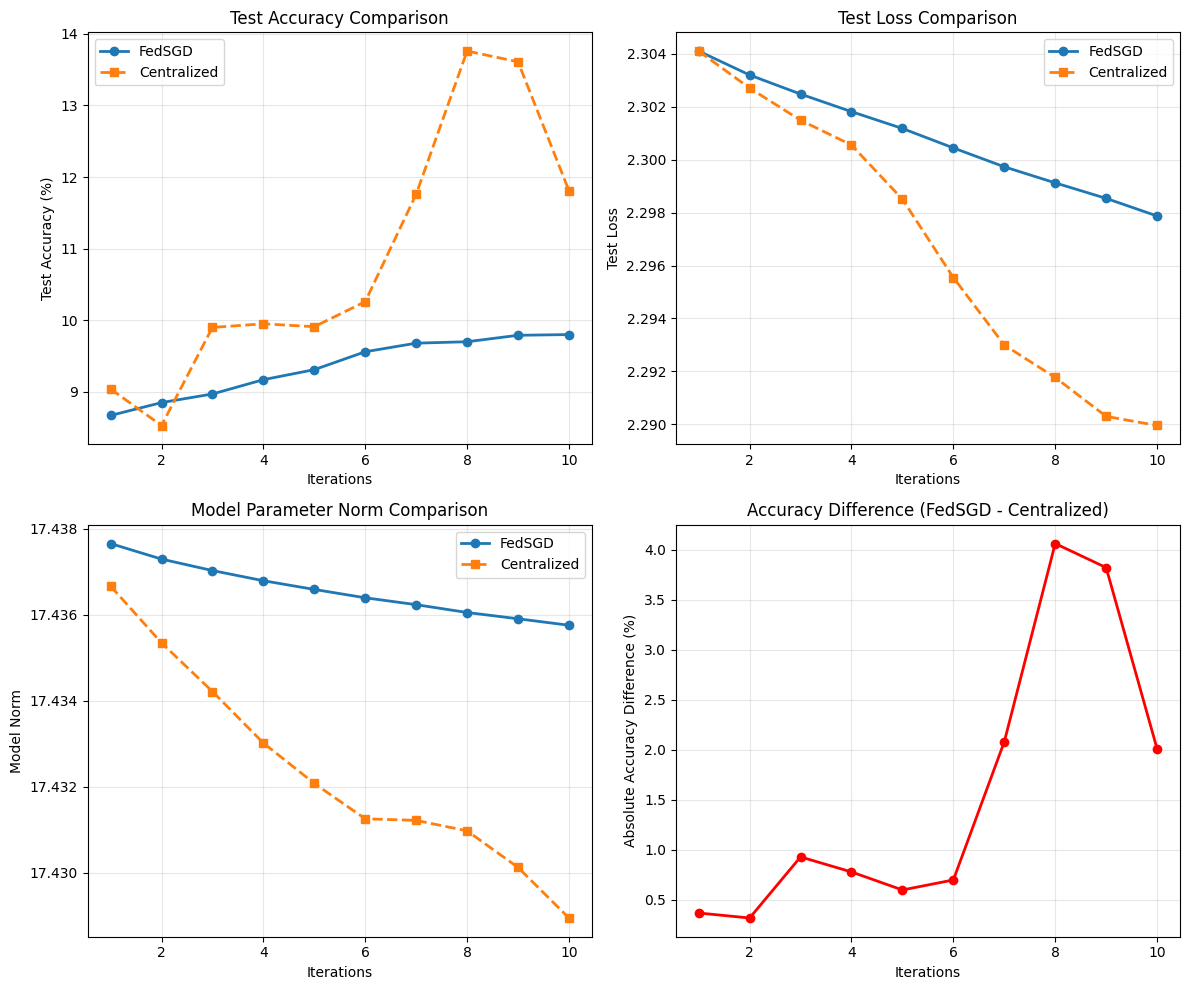

Results saved to ./results/task1_fedsgd_vs_centralized.pkl

TASK 1 COMPLETE

Conclusion:
FedSGD with K=1 and full client participation is theoretically equivalent
to centralized SGD when using the same learning rate and data ordering.

Theoretical Explanation:
In FedSGD, the global update is: θ^(t+1) = θ^(t) - η * Σ(N_i/N * ∇L_i(θ^(t)))
This equals: θ^(t+1) = θ^(t) - η * ∇L(θ^(t))
which is exactly the centralized SGD update, since L(θ) = Σ(N_i/N * L_i(θ))

Any observed differences are due to:
1. Floating point precision
2. Batch ordering (mitigated by shuffle=False)
3. Minor implementation details


In [5]:
print("\n" + "="*80)
print("COMPARING FEDSGD VS CENTRALIZED")
print("="*80)

# Compute difference in model parameters
param_diff = 0.0
for p1, p2 in zip(model_fedsgd.parameters(), model_centralized.parameters()):
    param_diff += torch.norm(p1 - p2).item()

print(f"\nTotal parameter difference: {param_diff:.6f}")
print("(Should be very close to 0 if implementations are equivalent)")

# Compute iteration-by-iteration differences
acc_diffs = [abs(a1 - a2) for a1, a2 in zip(fedsgd_history['test_accuracy'],
                                              centralized_history['test_accuracy'])]
loss_diffs = [abs(l1 - l2) for l1, l2 in zip(fedsgd_history['test_loss'],
                                               centralized_history['test_loss'])]
norm_diffs = [abs(n1 - n2) for n1, n2 in zip(fedsgd_history['model_norm'],
                                               centralized_history['model_norm'])]

print(f"\nAverage accuracy difference: {np.mean(acc_diffs):.6f}%")
print(f"Average loss difference: {np.mean(loss_diffs):.6f}")
print(f"Average model norm difference: {np.mean(norm_diffs):.6f}")

# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Test Accuracy
axes[0, 0].plot(fedsgd_history['iterations'], fedsgd_history['test_accuracy'],
                marker='o', label='FedSGD', linewidth=2)
axes[0, 0].plot(centralized_history['iterations'], centralized_history['test_accuracy'],
                marker='s', label='Centralized', linewidth=2, linestyle='--')
axes[0, 0].set_xlabel('Iterations')
axes[0, 0].set_ylabel('Test Accuracy (%)')
axes[0, 0].set_title('Test Accuracy Comparison')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Test Loss
axes[0, 1].plot(fedsgd_history['iterations'], fedsgd_history['test_loss'],
                marker='o', label='FedSGD', linewidth=2)
axes[0, 1].plot(centralized_history['iterations'], centralized_history['test_loss'],
                marker='s', label='Centralized', linewidth=2, linestyle='--')
axes[0, 1].set_xlabel('Iterations')
axes[0, 1].set_ylabel('Test Loss')
axes[0, 1].set_title('Test Loss Comparison')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Model Norm
axes[1, 0].plot(fedsgd_history['iterations'], fedsgd_history['model_norm'],
                marker='o', label='FedSGD', linewidth=2)
axes[1, 0].plot(centralized_history['iterations'], centralized_history['model_norm'],
                marker='s', label='Centralized', linewidth=2, linestyle='--')
axes[1, 0].set_xlabel('Iterations')
axes[1, 0].set_ylabel('Model Norm')
axes[1, 0].set_title('Model Parameter Norm Comparison')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Difference plot
axes[1, 1].plot(fedsgd_history['iterations'], acc_diffs, marker='o', linewidth=2, color='red')
axes[1, 1].set_xlabel('Iterations')
axes[1, 1].set_ylabel('Absolute Accuracy Difference (%)')
axes[1, 1].set_title('Accuracy Difference (FedSGD - Centralized)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('./results/task1_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Save results
results_task1 = {
    'fedsgd': fedsgd_history,
    'centralized': centralized_history,
    'param_difference': param_diff,
    'avg_acc_diff': np.mean(acc_diffs),
    'avg_loss_diff': np.mean(loss_diffs),
    'avg_norm_diff': np.mean(norm_diffs),
    'config': CONFIG
}
save_results(results_task1, 'task1_fedsgd_vs_centralized')

print("\n" + "="*80)
print("TASK 1 COMPLETE")
print("="*80)
print("\nConclusion:")
print("FedSGD with K=1 and full client participation is theoretically equivalent")
print("to centralized SGD when using the same learning rate and data ordering.")
print("\nTheoretical Explanation:")
print("In FedSGD, the global update is: θ^(t+1) = θ^(t) - η * Σ(N_i/N * ∇L_i(θ^(t)))")
print("This equals: θ^(t+1) = θ^(t) - η * ∇L(θ^(t))")
print("which is exactly the centralized SGD update, since L(θ) = Σ(N_i/N * L_i(θ))")
print("\nAny observed differences are due to:")
print("1. Floating point precision")
print("2. Batch ordering (mitigated by shuffle=False)")
print("3. Minor implementation details")